In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
print(sys.executable)

c:\Users\apraj\AppData\Local\Programs\Python\Python313\python.exe


In [3]:
import os
print(os.getcwd())  # shows where Python thinks it currently is

e:\IPL-Win-Predictor\notebook


In [8]:
matches = pd.read_csv('E:/IPL-Win-Predictor/data/matches.csv')
deliveries = pd.read_csv('E:/IPL-Win-Predictor/data/deliveries.csv')


In [9]:
matches.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [10]:
deliveries.head()

,match_id,inning,batting_team,bowling_team,over,ball,batter,bowler,non_striker,batsman_runs,extra_runs,total_runs,extras_type,is_wicket,player_dismissed,dismissal_kind,fielder
0,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,SC Ganguly,P Kumar,BB McCullum,0,1,1,legbyes,0,NaN,NaN,NaN
1,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
2,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,BB McCullum,P Kumar,SC Ganguly,0,1,1,wides,0,NaN,NaN,NaN
3,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN
4,335982,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,5,BB McCullum,P Kumar,SC Ganguly,0,0,0,NaN,0,NaN,NaN,NaN


In [11]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 20 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               1095 non-null   int64  
 1   season           1095 non-null   object 
 2   city             1044 non-null   object 
 3   date             1095 non-null   object 
 4   match_type       1095 non-null   object 
 5   player_of_match  1090 non-null   object 
 6   venue            1095 non-null   object 
 7   team1            1095 non-null   object 
 8   team2            1095 non-null   object 
 9   toss_winner      1095 non-null   object 
 10  toss_decision    1095 non-null   object 
 11  winner           1090 non-null   object 
 12  result           1095 non-null   object 
 13  result_margin    1076 non-null   float64
 14  target_runs      1092 non-null   float64
 15  target_overs     1092 non-null   float64
 16  super_over       1095 non-null   object 
 17  method        

In [12]:
deliveries.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 260920 entries, 0 to 260919
Data columns (total 17 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   match_id          260920 non-null  int64 
 1   inning            260920 non-null  int64 
 2   batting_team      260920 non-null  object
 3   bowling_team      260920 non-null  object
 4   over              260920 non-null  int64 
 5   ball              260920 non-null  int64 
 6   batter            260920 non-null  object
 7   bowler            260920 non-null  object
 8   non_striker       260920 non-null  object
 9   batsman_runs      260920 non-null  int64 
 10  extra_runs        260920 non-null  int64 
 11  total_runs        260920 non-null  int64 
 12  extras_type       14125 non-null   object
 13  is_wicket         260920 non-null  int64 
 14  player_dismissed  12950 non-null   object
 15  dismissal_kind    12950 non-null   object
 16  fielder           9354 non-null    obj

In [13]:
matches.shape
deliveries.shape

(260920, 17)

In [14]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

In [15]:
matches = matches[matches['result'] != 'no result']

In [16]:
matches = matches[matches['method'] != 'D/L']

In [17]:
matches.isnull().sum()

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       0
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                0
result                0
result_margin        14
target_runs           0
target_overs          0
super_over            0
method             1069
umpire1               0
umpire2               0
dtype: int64

In [18]:
deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      247970
fielder             251566
dtype: int64

In [19]:
matches = matches[['id', 'season', 'team1', 'team2', 'toss_winner', 
                   'toss_decision', 'venue', 'winner']]

In [24]:
# Fix team name inconsistencies
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Kings XI Punjab': 'Punjab Kings'
}

matches.replace(team_mapping, inplace=True)
deliveries.replace(team_mapping, inplace=True)

# Check basic info
print(matches.shape)
matches.head()

(1069, 8)


,id,season,team1,team2,toss_winner,toss_decision,venue,winner
0,335982,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders
1,335983,2007/08,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings
2,335984,2007/08,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Capitals
3,335985,2007/08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore
4,335986,2007/08,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Eden Gardens,Kolkata Knight Riders


In [25]:
print(matches.columns)
matches.columns = matches.columns.str.strip()

Index(['id', 'season', 'team1', 'team2', 'toss_winner', 'toss_decision',
       'venue', 'winner'],
      dtype='object')


In [26]:
# Count total wins by each team
team_wins = matches['winner'].value_counts()

print(team_wins)

winner
Mumbai Indians                 144
Chennai Super Kings            135
Kolkata Knight Riders          127
Sunrisers Hyderabad            115
Royal Challengers Bangalore    113
Delhi Capitals                 113
Rajasthan Royals               111
Punjab Kings                   109
Gujarat Titans                  28
Lucknow Super Giants            24
Gujarat Lions                   13
Pune Warriors                   12
Rising Pune Supergiant          10
Royal Challengers Bengaluru      7
Kochi Tuskers Kerala             5
Rising Pune Supergiants          3
Name: count, dtype: int64


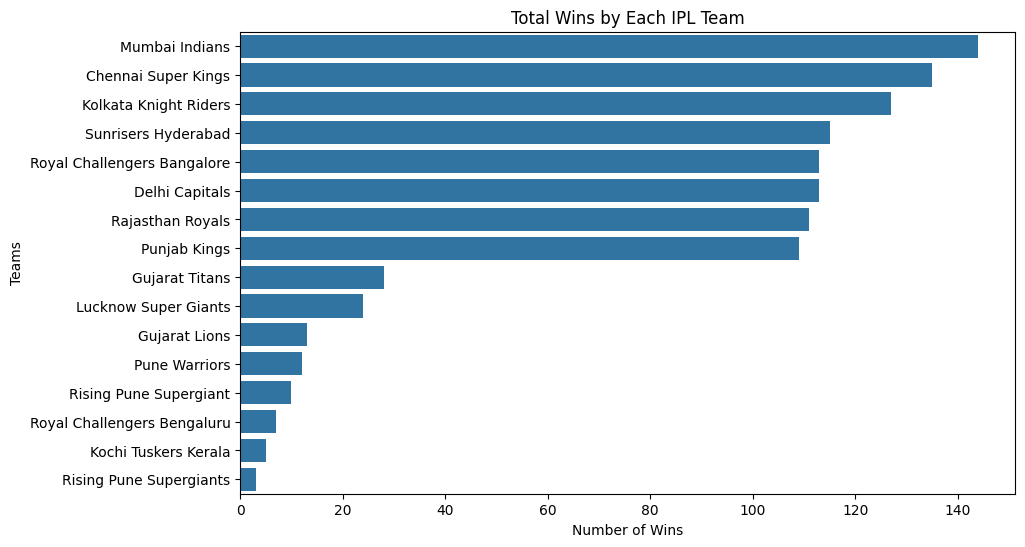

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=team_wins.values, y=team_wins.index)

plt.title('Total Wins by Each IPL Team')
plt.xlabel('Number of Wins')
plt.ylabel('Teams')

plt.show()

In [28]:
# Create a column: did toss winner also win match?
matches['toss_win_match_win'] = matches['toss_winner'] == matches['winner']

# Calculate percentage
toss_win_pct = matches['toss_win_match_win'].mean() * 100

print(f"Toss winner also won match: {toss_win_pct:.2f}%")

Toss winner also won match: 50.80%


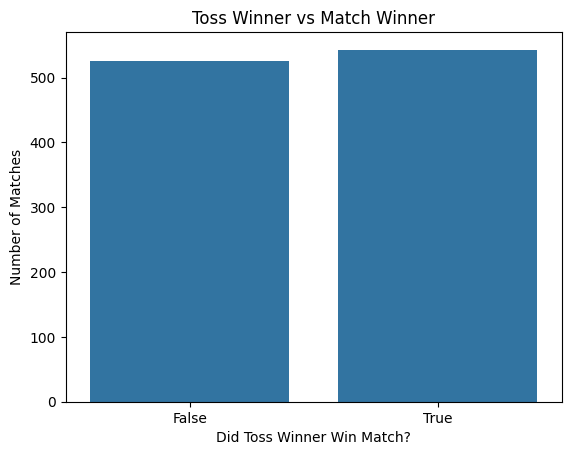

In [29]:
sns.countplot(x='toss_win_match_win', data=matches)

plt.title('Toss Winner vs Match Winner')
plt.xlabel('Did Toss Winner Win Match?')
plt.ylabel('Number of Matches')

plt.show()

Insight:
Winning the toss does not significantly impact match outcomes.
The win percentage is close to 50%, indicating that toss advantage is largely a myth.

In [30]:
# Team batting second = team2
# If winner == team2 → chasing team won

matches['chasing_win'] = matches['winner'] == matches['team2']

In [31]:
venue_chase_pct = matches.groupby('venue')['chasing_win'].mean() * 100

# Sort for better view
venue_chase_pct = venue_chase_pct.sort_values(ascending=False)

print(venue_chase_pct.head(10))

venue
Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket Stadium     81.818182
Nehru Stadium                                           75.000000
Subrata Roy Sahara Stadium                              75.000000
St George's Park                                        71.428571
Saurashtra Cricket Association Stadium                  70.000000
Sharjah Cricket Stadium                                 64.285714
Maharashtra Cricket Association Stadium                 63.636364
Punjab Cricket Association IS Bindra Stadium, Mohali    63.636364
Zayed Cricket Stadium, Abu Dhabi                        62.500000
Sheikh Zayed Stadium                                    62.068966
Name: chasing_win, dtype: float64


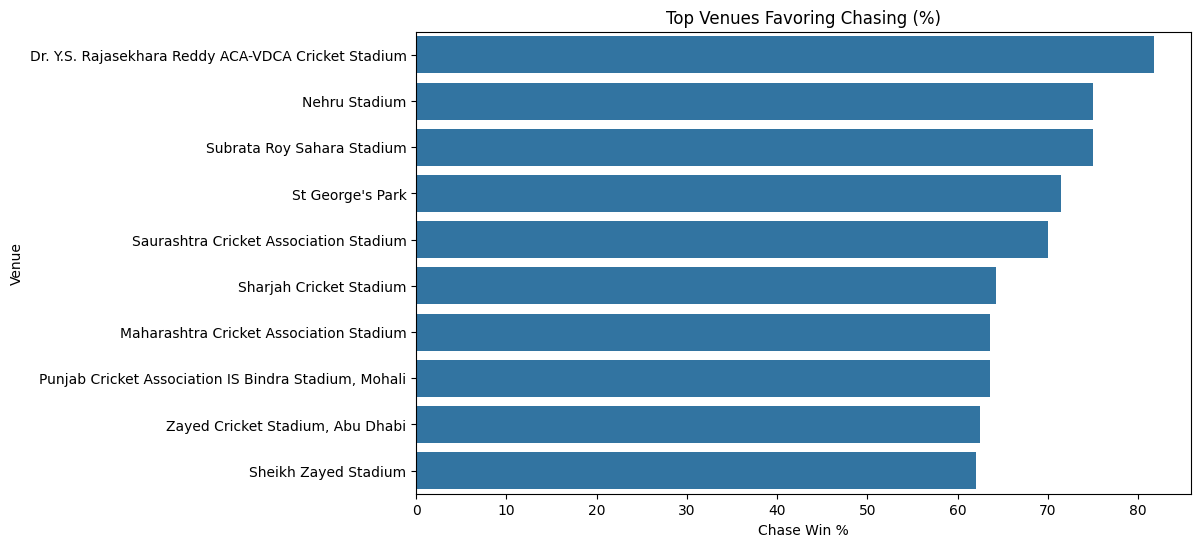

In [32]:
plt.figure(figsize=(10,6))
sns.barplot(x=venue_chase_pct.values[:10], y=venue_chase_pct.index[:10])

plt.title('Top Venues Favoring Chasing (%)')
plt.xlabel('Chase Win %')
plt.ylabel('Venue')

plt.show()

Insight:
Chasing success varies significantly across venues. Some stadiums strongly favor chasing,
while others favor defending. This suggests that pitch conditions and ground dimensions
play an important role in match outcomes.

In [33]:
# Filter first innings
first_innings = deliveries[deliveries['inning'] == 1]

# Total runs per match
first_innings_total = first_innings.groupby('match_id')['total_runs'].sum().reset_index()

first_innings_total.head()

,match_id,total_runs
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110


In [34]:
match_runs = matches.merge(first_innings_total, left_on='id', right_on='match_id')

In [35]:
avg_score_season = match_runs.groupby('season')['total_runs'].mean()

print(avg_score_season)

season
2007/08    161.946429
2009       150.333333
2009/10    164.783333
2011       155.550725
2012       157.540541
2013       155.894737
2014       163.406780
2015       165.654545
2016       164.339286
2017       166.431034
2018       172.070175
2019       168.508475
2020/21    169.500000
2021       159.316667
2022       171.121622
2023       182.985915
2024       189.591549
Name: total_runs, dtype: float64


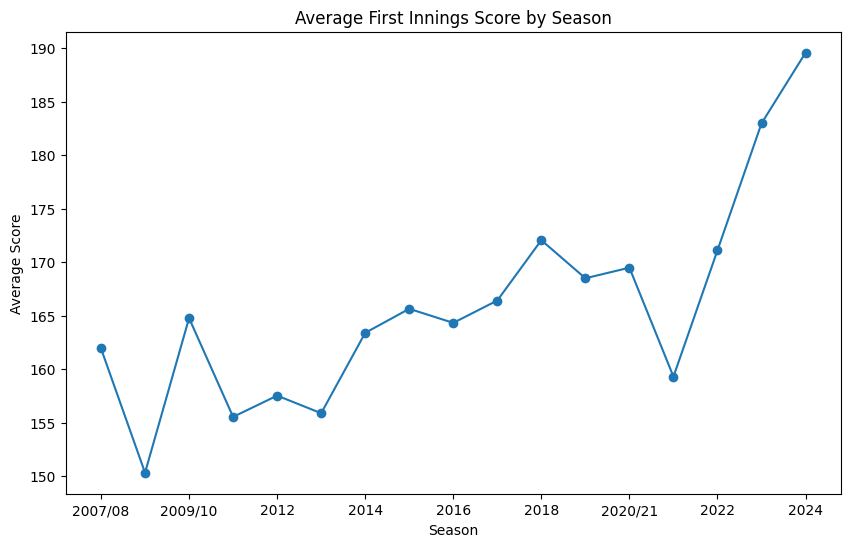

In [36]:
plt.figure(figsize=(10,6))
avg_score_season.plot(marker='o')

plt.title('Average First Innings Score by Season')
plt.xlabel('Season')
plt.ylabel('Average Score')

plt.show()

Insight:
Average first innings scores have increased over time in the IPL.
This indicates a shift towards more aggressive batting strategies,
better pitch conditions, and improved player skills.

In [37]:
# First innings total already created earlier
# Rename for clarity

first_innings_total.rename(columns={'total_runs': 'target'}, inplace=True)

first_innings_total.head()

,match_id,target
0,335982,222
1,335983,240
2,335984,129
3,335985,165
4,335986,110


In [38]:
match_data = matches.merge(first_innings_total, left_on='id', right_on='match_id')

match_data.head()

,id,season,team1,team2,toss_winner,toss_decision,venue,winner,toss_win_match_win,chasing_win,match_id,target
0,335982,2007/08,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders,False,True,335982,222
1,335983,2007/08,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,True,True,335983,240
2,335984,2007/08,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Capitals,False,False,335984,129
3,335985,2007/08,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore,False,True,335985,165
4,335986,2007/08,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Eden Gardens,Kolkata Knight Riders,False,False,335986,110


In [39]:
match_data['chasing_win'] = match_data['winner'] == match_data['team2']

In [40]:
match_data['toss_chose_field'] = match_data['toss_decision'] == 'field'

In [41]:
team_win_rate = matches['winner'].value_counts(normalize=True)

match_data['team1_win_rate'] = match_data['team1'].map(team_win_rate)
match_data['team2_win_rate'] = match_data['team2'].map(team_win_rate)

In [42]:
match_data['venue_chase_win_pct'] = match_data['venue'].map(venue_chase_pct / 100)

In [57]:
# Calculate win rate
team_win_rate = matches['winner'].value_counts(normalize=True)

# Extract year safely
match_data['season'] = match_data['season'].astype(str).str.split('/').str[1]

# Convert to numeric safely
match_data['season'] = pd.to_numeric(match_data['season'], errors='coerce')

# Fill missing values
match_data['season'] = match_data['season'].fillna(match_data['season'].median())

# Now normalize
match_data['season_norm'] = (
    (match_data['season'] - match_data['season'].min()) /
    (match_data['season'].max() - match_data['season'].min())
)

In [63]:
# Sort matches properly (important)
matches_sorted = matches.sort_values(['season', 'id'])

team_last5 = {}
recent_form_list = []

for _, row in matches_sorted.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    winner = row['winner']
    
    def get_recent_win_rate(team):
        history = team_last5.get(team, [])
        return sum(history[-5:]) / 5 if len(history) >= 5 else 0.5
    
    recent_form_list.append({
        'id': row['id'],
        'team1_recent': get_recent_win_rate(team1),
        'team2_recent': get_recent_win_rate(team2)
    })
    
    # Update history
    team_last5.setdefault(team1, []).append(1 if winner == team1 else 0)
    team_last5.setdefault(team2, []).append(1 if winner == team2 else 0)

# Convert to dataframe
recent_form_df = pd.DataFrame(recent_form_list)

# Merge into main dataset
match_data = match_data.merge(recent_form_df, on='id')

In [66]:
match_data[['team1_recent', 'team2_recent']].head()

,team1_recent,team2_recent
0,0.5,0.5
1,0.5,0.5
2,0.5,0.5
3,0.5,0.5
4,0.5,0.5


In [67]:
X = match_data[features]

In [68]:
# Sort matches by season (important)
matches_sorted = matches.sort_values('season')

# Create empty dict
recent_form = {}

# Store results
team_last5 = {}

recent_form_list = []

for _, row in matches_sorted.iterrows():
    team1 = row['team1']
    team2 = row['team2']
    winner = row['winner']
    
    # Get last 5 results
    def get_recent_win_rate(team):
        history = team_last5.get(team, [])
        return sum(history[-5:]) / 5 if len(history) >= 5 else 0.5
    
    recent_form_list.append({
        'id': row['id'],
        'team1_recent': get_recent_win_rate(team1),
        'team2_recent': get_recent_win_rate(team2)
    })
    
    # Update history
    team_last5.setdefault(team1, []).append(1 if winner == team1 else 0)
    team_last5.setdefault(team2, []).append(1 if winner == team2 else 0)

recent_form_df = pd.DataFrame(recent_form_list)

# Merge
match_data = match_data.merge(recent_form_df, on='id')

MergeError: Passing 'suffixes' which cause duplicate columns {'team1_recent_x', 'team2_recent_x'} is not allowed.

In [ ]:
match_data.head()

,id,season,team1,team2,toss_winner,toss_decision,venue,winner,toss_win_match_win,chasing_win,...,target,toss_chose_field,team1_win_rate,team2_win_rate,venue_chase_win_pct,team1_recent_x,team2_recent_x,season_norm,team1_recent_y,team2_recent_y
0,335982,8.0,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Kolkata Knight Riders,False,True,...,222,True,0.105706,0.118803,0.516667,0.5,0.5,0.0,0.5,0.5
1,335983,8.0,Punjab Kings,Chennai Super Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chennai Super Kings,True,True,...,240,False,0.101964,0.126286,0.485714,0.6,0.8,0.0,0.6,0.8
2,335984,8.0,Delhi Capitals,Rajasthan Royals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi Capitals,False,False,...,129,False,0.105706,0.103835,0.543860,0.6,0.8,0.0,0.6,0.8
3,335985,8.0,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Wankhede Stadium,Royal Challengers Bangalore,False,True,...,165,False,0.134705,0.105706,0.438356,0.4,0.4,0.0,0.4,0.4
4,335986,8.0,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,bat,Eden Gardens,Kolkata Knight Riders,False,False,...,110,False,0.118803,0.107577,0.410959,0.6,0.0,0.0,0.6,0.0


In [ ]:
print(match_data['season'].head())
print(match_data['season'].dtype)

0    8.0
1    8.0
2    8.0
3    8.0
4    8.0
Name: season, dtype: float64
float64


In [ ]:
# Fix season format (in case not done)
match_data['season'] = match_data['season'].astype(str).str.split('/').str[1].astype(int)

# Create season_norm
match_data['season_norm'] = (
    (match_data['season'] - match_data['season'].min()) /
    (match_data['season'].max() - match_data['season'].min())
)

IntCastingNaNError: Cannot convert non-finite values (NA or inf) to integer

In [ ]:
features = [
    'target',
    'team1_win_rate',
    'team2_win_rate',
    'venue_chase_win_pct',
    'toss_chose_field',
    'season_norm',
    'team1_recent',
    'team2_recent'
]

In [69]:
X = match_data[features]
y = match_data['chasing_win']

In [71]:
X = X.astype(float)
y = y.astype(int)

In [73]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [75]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [77]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train_scaled, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [79]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [81]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.60


In [82]:
from sklearn.metrics import roc_auc_score

roc_auc = roc_auc_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")

ROC-AUC Score: 0.64


In [83]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[64 45]
 [41 64]]


Insight:
The model achieves moderate accuracy, which is expected in T20 cricket due to its unpredictable nature.
It performs better than random guessing but is not overly confident, indicating realistic modeling.

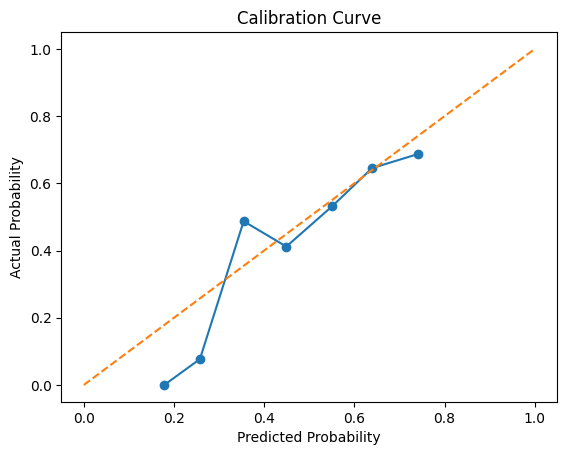

In [84]:
from sklearn.calibration import calibration_curve
import matplotlib.pyplot as plt

prob_true, prob_pred = calibration_curve(y_test, y_prob, n_bins=10)

plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')

plt.title('Calibration Curve')
plt.xlabel('Predicted Probability')
plt.ylabel('Actual Probability')

plt.show()

Insight:
The calibration curve shows how well predicted probabilities match actual outcomes.
A well-calibrated model means predicted probabilities can be trusted for decision-making.

In [85]:
# Add predictions to dataframe
results = X_test.copy()
results['actual'] = y_test.values
results['predicted'] = y_pred
results['probability'] = y_prob

results.head()

,target,team1_win_rate,team2_win_rate,venue_chase_win_pct,toss_chose_field,season_norm,team1_recent,team2_recent,actual,predicted,probability
352,171.0,0.103835,0.105706,0.391304,1.0,0.153846,0.6,0.6,0,0,0.403542
102,134.0,0.105706,0.105706,0.250000,0.0,0.153846,0.6,0.8,0,0,0.267612
232,198.0,0.101964,0.107577,0.444444,1.0,0.153846,0.8,0.4,1,0,0.397980
473,134.0,0.126286,0.118803,0.291667,1.0,0.153846,0.6,0.8,0,0,0.402090
368,152.0,0.011225,0.118803,0.750000,0.0,0.153846,0.0,0.4,1,1,0.728285


In [86]:
# Incorrect predictions
errors = results[results['actual'] != results['predicted']]

errors.head()

,target,team1_win_rate,team2_win_rate,venue_chase_win_pct,toss_chose_field,season_norm,team1_recent,team2_recent,actual,predicted,probability
232,198.0,0.101964,0.107577,0.444444,1.0,0.153846,0.8,0.4,1,0,0.397980
345,159.0,0.118803,0.134705,0.410959,0.0,0.153846,0.2,0.6,1,0,0.408467
1021,196.0,0.103835,0.026193,0.500000,1.0,0.153846,1.0,0.4,1,0,0.389436
951,154.0,0.022451,0.103835,0.500000,1.0,0.153846,0.6,0.8,0,1,0.503338
25,144.0,0.126286,0.107577,0.291667,1.0,0.000000,0.6,0.2,1,0,0.456049


Insight:
The model tends to make errors in high target matches and certain venues,
indicating that match context and extreme conditions are harder to predict.

In [87]:
coefficients = pd.DataFrame({
    'Feature': features,
    'Coefficient': model.coef_[0]
}).sort_values(by='Coefficient', ascending=False)

coefficients

,Feature,Coefficient
3,venue_chase_win_pct,0.466982
4,toss_chose_field,0.178193
2,team2_win_rate,0.098598
1,team1_win_rate,0.050453
6,team1_recent,-0.034581
7,team2_recent,-0.104071
5,season_norm,-0.107989
0,target,-0.357103


Insight:
Target score has the strongest negative impact on chasing success,
while venue conditions and team form also play important roles.